In [7]:
import numpy as np
import matplotlib.pyplot as plt
import postgkyl as pg
import glob

Detected steps: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Steps used: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


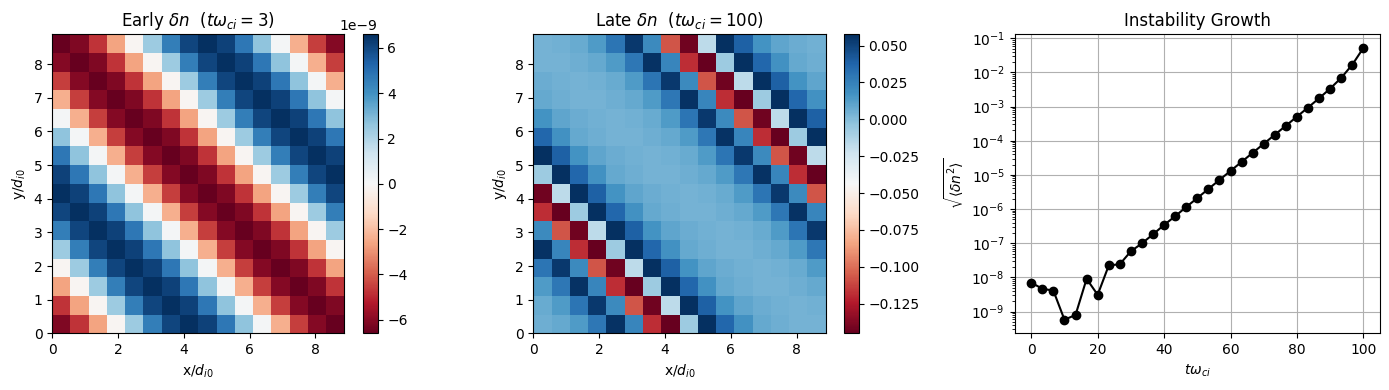

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import postgkyl as pg
import glob

# --------------------------------------------------
# Directory
# --------------------------------------------------

basedir = "/dartfs-hpc/rc/home/7/f006xp7/gkeyll_tests/weibel_2x2v/"

# --------------------------------------------------
# Physical normalization
# --------------------------------------------------

qe = 1.0
me = 1.0
B0 = 1.0

wci = qe*B0/me     # cyclotron frequency
t_end = 100.0
num_frames = 30

dt_frame = t_end/num_frames

# --------------------------------------------------
# Detect files
# --------------------------------------------------

files = glob.glob(f"{basedir}/drift_wave_instability-elc_M0_*.gkyl")

steps = []

for f in files:
    step = int(f.split("_")[-1].split(".")[0])
    steps.append(step)

steps = sorted(steps)

print("Detected steps:", steps)

if len(steps) == 0:
    raise RuntimeError("No M0 files detected")

# --------------------------------------------------
# Load density
# --------------------------------------------------

def load_ne(step):

    data = pg.GData(f"{basedir}/drift_wave_instability-elc_M0_{step}.gkyl")
    interp = pg.GInterpModal(data,1,"ms")

    grid,values = interp.interpolate()

    x = grid[0]
    y = grid[1]

    ne = values[:,:,0]

    xc = 0.5*(x[:-1] + x[1:])
    yc = 0.5*(y[:-1] + y[1:])

    return xc,yc,ne

# --------------------------------------------------
# Density fluctuation
# --------------------------------------------------

def density_fluctuation(ne):

    mean_profile = np.mean(ne,axis=1)[:,None]
    dn = ne - mean_profile

    return dn

# --------------------------------------------------
# RMS fluctuation vs time
# --------------------------------------------------

rms = []
time = []

for s in steps:

    try:

        x,y,ne = load_ne(s)
        dn = density_fluctuation(ne)

        rms.append(np.sqrt(np.mean(dn**2)))

        t = s*dt_frame
        time.append(t*wci)

    except:
        break

steps = steps[:len(rms)]

print("Steps used:",steps)

# --------------------------------------------------
# Early and late snapshots
# --------------------------------------------------

early_step = steps[1]
late_step  = steps[-1]

x,y,ne_early = load_ne(early_step)
dn_early = density_fluctuation(ne_early)

x,y,ne_late = load_ne(late_step)
dn_late = density_fluctuation(ne_late)

# --------------------------------------------------
# Plot
# --------------------------------------------------

fig,axs = plt.subplots(1,3,figsize=(14,4))

# --------------------------------------------------
# Early δn
# --------------------------------------------------

im0 = axs[0].pcolormesh(x,y,dn_early.T,cmap="RdBu")
# axs[0].set_title(f"Early $\\delta n$  ($t\\omega_{{ci}}={time[1]:.2f}$)")
axs[0].set_title(f"Early $\\delta n$  ($t\\omega_{{ci}}={time[1]:.0f}$)")
axs[0].set_xlabel("x/$d_{i0}$")
axs[0].set_ylabel("y/$d_{i0}$")

plt.colorbar(im0,ax=axs[0])

# --------------------------------------------------
# Late δn
# --------------------------------------------------

im1 = axs[1].pcolormesh(x,y,dn_late.T,cmap="RdBu")
axs[1].set_title(f"Late $\\delta n$  ($t\\omega_{{ci}}={time[-1]:.0f}$)")
axs[1].set_xlabel("x/$d_{i0}$")
axs[1].set_ylabel("y/$d_{i0}$")

plt.colorbar(im1,ax=axs[1])

# --------------------------------------------------
# Growth curve
# --------------------------------------------------

axs[2].plot(time,rms,'o-',color='black')

axs[2].set_yscale("log")

axs[2].set_xlabel(r"$t\omega_{ci}$")
axs[2].set_ylabel(r"$\sqrt{\langle \delta n^2\rangle}$")

axs[2].set_title("Instability Growth")

axs[2].grid(True)

plt.tight_layout()
plt.savefig("weibel_validation_3panel.png", dpi=600, bbox_inches="tight")

plt.show()